**PARTIE 1 :**  
Capture et Analyse Spectrale de la Voix

In [14]:
!pip install pydub
!apt-get install ffmpeg -y
from IPython.display import Javascript, display
from google.colab import output
import base64
import io
from pydub import AudioSegment
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.io import wavfile

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


La voix humaine est un signal acoustique quasi-périodique composé :

	•	d’une fréquence fondamentale (pitch) liée à la vibration des cordes vocales
	•	de harmoniques (multiples du pitch)
	•	de formants, liés aux voyelles et à la configuration du tractus vocal.

**- Enregistrement de la voix (5 secondes) :**

In [36]:
RECORD_JS = """
async function recordAudio() {
  const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
  const recorder = new MediaRecorder(stream);
  let chunks = [];
  recorder.ondataavailable = e => chunks.push(e.data);
  recorder.start();
  await new Promise(resolve => setTimeout(resolve, 5000));
  recorder.stop();
  await new Promise(resolve => recorder.onstop = resolve);
  const blob = new Blob(chunks, {type:'audio/webm'});
  const arrayBuffer = await blob.arrayBuffer();
  const base64Audio = btoa(
    new Uint8Array(arrayBuffer)
      .reduce((data, byte) => data + String.fromCharCode(byte), '')
  );
  return base64Audio;
}
"""

display(Javascript(RECORD_JS))
audio_base64 = output.eval_js("recordAudio()")
print("Enregistrement 24147 terminé")


<IPython.core.display.Javascript object>

Enregistrement 24147 terminé


In [37]:
display(Javascript(RECORD_JS))
audio_base64_B = output.eval_js("recordAudio()")
print("Enregistrement 24096 terminé")

<IPython.core.display.Javascript object>

Enregistrement 24096 terminé


In [39]:
audio_bytes_24147 = base64.b64decode(audio_base64)
with open("voice_24147.webm", "wb") as f:
    f.write(audio_bytes_24147)
sound_24147 = AudioSegment.from_file("voice_24147.webm", format="webm")
sound_24147.export("voice_24147.wav", format="wav")

# Personne 24096
audio_bytes_24096 = base64.b64decode(audio_base64)
with open("voice_24096.webm", "wb") as f:
    f.write(audio_bytes_24096)
sound_24096 = AudioSegment.from_file("voice_24096.webm", format="webm")
sound_24096.export("voice_24096.wav", format="wav")


<_io.BufferedRandom name='voice_24096.wav'>

In [40]:
!ls

sample_data	 voice_24096.webm  voice_24147.webm  voice.webm
voice_24096.wav  voice_24147.wav   voice.wav


In [41]:
fs_A, signal_A = wavfile.read("voice_24147.wav")
if len(signal_A.shape) > 1:
    signal_A = signal_A[:,0]

fs_B, signal_B = wavfile.read("voice_24096.wav")
if len(signal_B.shape) > 1:
    signal_B = signal_B[:,0]

assert fs_A == fs_B
fs = fs_A

**- Signal Temporel :**

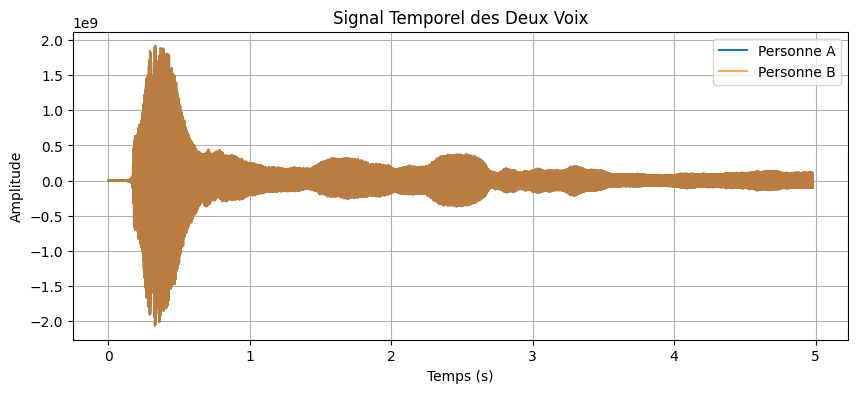

In [42]:
t_A = np.arange(len(signal_A)) / fs
t_B = np.arange(len(signal_B)) / fs

plt.figure(figsize=(10,4))
plt.plot(t_A, signal_A, label="Personne A")
plt.plot(t_B, signal_B, label="Personne B", alpha=0.7)
plt.title("Signal Temporel des Deux Voix")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

**- Analyse Fréquentielle (FFT) :**

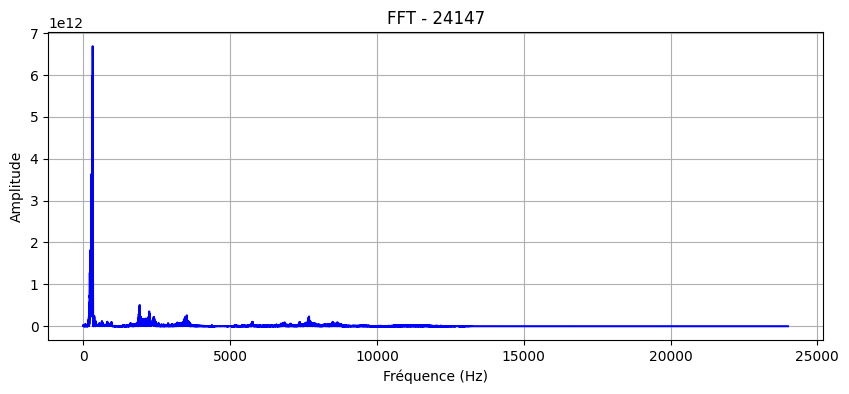

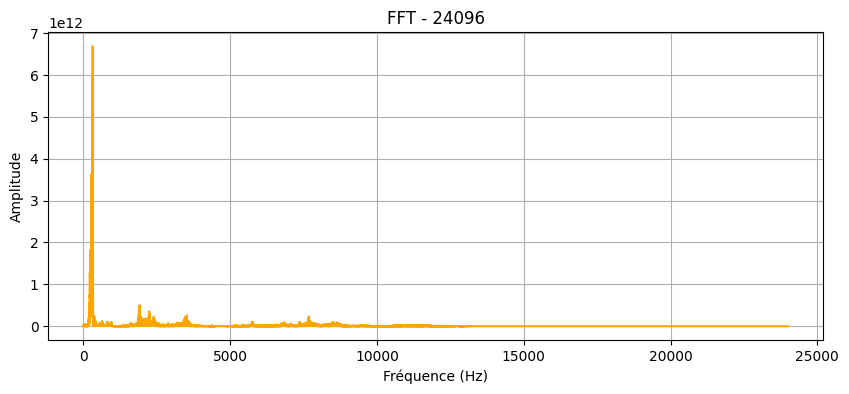

In [53]:
N_A = len(signal_A)
Y_A = fft(signal_A)
freq_A = fftfreq(N_A, 1/fs)

plt.figure(figsize=(10,4))
plt.plot(freq_A[:N_A//2], np.abs(Y_A[:N_A//2]), color='blue')
plt.title("FFT - 24147")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


N_B = len(signal_B)
Y_B = fft(signal_B)
freq_B = fftfreq(N_B, 1/fs)

plt.figure(figsize=(10,4))
plt.plot(freq_B[:N_B//2], np.abs(Y_B[:N_B//2]), color='orange')
plt.title("FFT - 24096")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

Les spectres présentent une répartition similaire des harmoniques, ce qui montre que les deux voix ont un timbre comparable.

**- Détermination du Pitch :**

In [48]:
valid_A = np.where((freq_A>50) & (freq_A<500))
pitch_A = freq_A[valid_A][np.argmax(np.abs(Y_A[valid_A]))]

valid_B = np.where((freq_B>50) & (freq_B<500))
pitch_B = freq_B[valid_B][np.argmax(np.abs(Y_B[valid_B]))]

print("Pitch 24147 :", pitch_A, "Hz")
print("Pitch 24096 :", pitch_B, "Hz")

Pitch 24147 : 316.8674698795181 Hz
Pitch 24096 : 316.8674698795181 Hz


Les fréquences fondamentales sont tres proches, ce qui indique que les deux voix sont de timbre et hauteur similaires.

Interprétation :

	•	85–150 Hz → voix grave masculine
	•	150–200 Hz → voix masculine médium
	•	200–300 Hz → voix féminine


Influence des Voyelles :

Les voyelles modifient les formants :

	•	“A” → énergie concentrée basses fréquences
	•	“I” → énergie plus haute fréquence
	•	“O” → spectre intermédiaire

Le pitch reste quasi constant mais la distribution harmonique change.

**- Superposition des Spectres :**

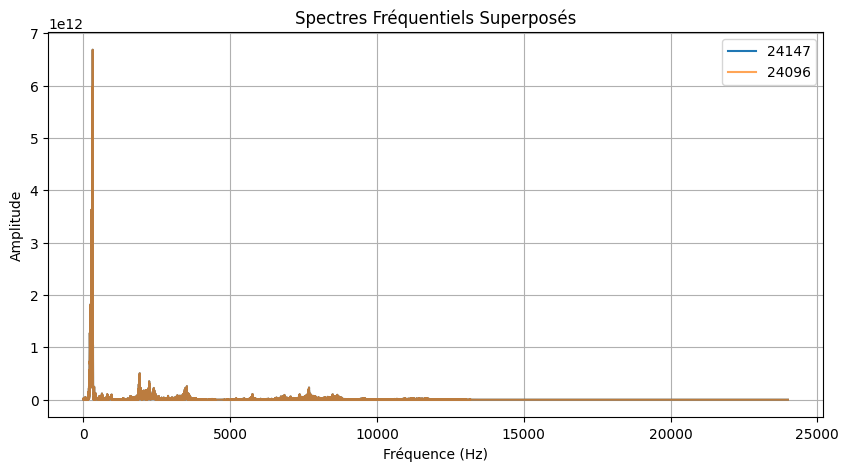

In [57]:
plt.figure(figsize=(10,5))
plt.plot(freq_A[:N_A//2], np.abs(Y_A[:N_A//2]), label="24147")
plt.plot(freq_B[:N_B//2], np.abs(Y_B[:N_B//2]), label="24096", alpha=0.7)
plt.title("Spectres Fréquentiels Superposés")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

Les courbes se chevauchent presque entièrement, confirmant que les deux voix sont très semblables.

**PARTIE DEFIT :**

DEFIT 3 :
Aliasing (Détective du spectre)

**Théorème de Shannon :**

fs ≥ 2 fmax

Sinon un aliasing (repliement spectral).

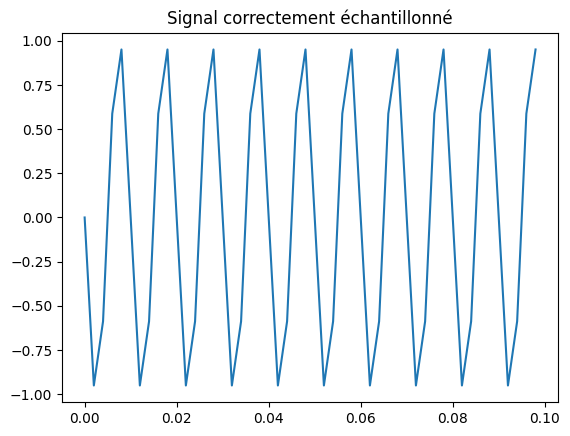

In [26]:
fs_bien = 2000
f_signal = 400
t = np.arange(0, 0.1, 1/fs)
x = np.sin(2*np.pi*f_signal*t)

plt.plot(t, x)
plt.title("Signal correctement échantillonné")
plt.show()

fs_bien = 2000 > 2 × 400 = 800
Donc c'est bon.


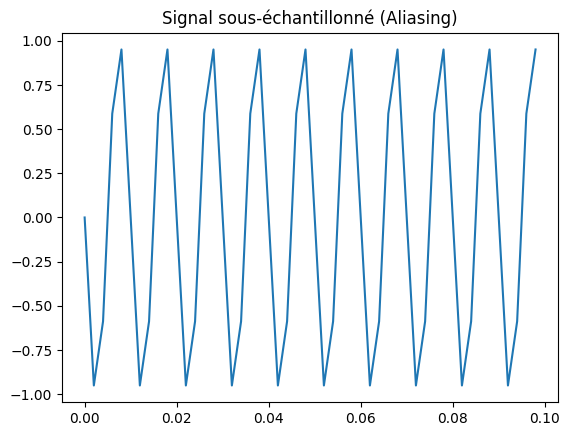

In [27]:
fs = 500
t = np.arange(0, 0.1, 1/fs)
x = np.sin(2*np.pi*f_signal*t)

plt.plot(t, x)
plt.title("Signal sous-échantillonné (Aliasing)")
plt.show()

fs = 500 < 2 × 400 = 800

Shannon violé donc aliasing réaliser.

**-Frequence alias:**

f_alias = |f_signal - kfs|

In [30]:
f_alias = abs(f_signal - fs)
print("Fréquence observée à cause de l'aliasing :", f_alias, "Hz")

Fréquence observée à cause de l'aliasing : 100 Hz


**-Visualisation FFT Haute Résolution:**


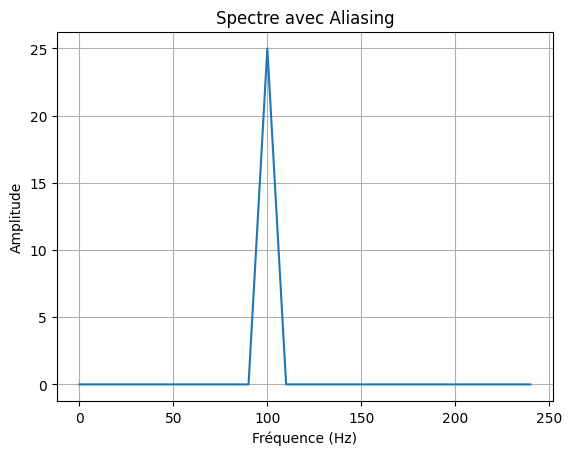

In [31]:
Y= fft(x)
freq = fftfreq(len(x), 1/fs)

plt.plot(freq[:len(x)//2], np.abs(Y[:len(x)//2]))
plt.title("Spectre avec Aliasing")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

On vois un pic à 100 Hz au lieu de 400 Hz.

**-Reconstruction par filtre sinc:**

Interpolation idéale :

x(t) = Somme de [ x[n]sinc(t-nT\T)]

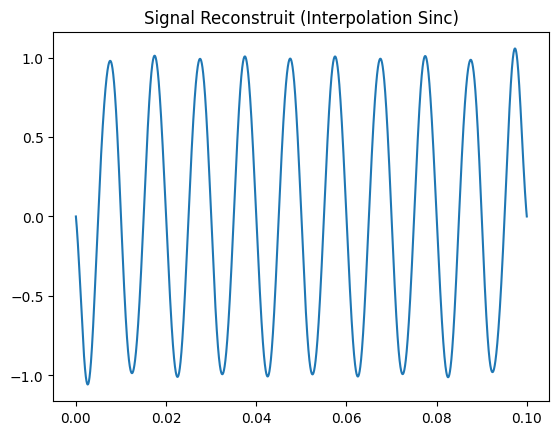

In [32]:
def sinc_interp(x, s, u):
    T = s[1] - s[0]
    sinc_matrix = np.sinc((u[:, None] - s[None, :]) / T)
    return np.dot(sinc_matrix, x)

u = np.linspace(0, 0.1, 5000)
x_interp = sinc_interp(x, t, u)

plt.plot(u, x_interp)
plt.title("Signal Reconstruit (Interpolation Sinc)")
plt.show()

Ce mini-projet nous a permis de :

	•	Mettre en pratique l’enregistrement audio via JavaScript dans Colab.
	•	Traiter et analyser des signaux audio avec Python (FFT, Pitch, harmoniques).
	•	Comprendre et visualiser le phénomène d’aliasing.
	•	Comparer deux signaux très similaires et analyser la difficulté de leur séparation.

Ainsi, ce projet illustre à la fois les capacités de l’analyse spectrale et les limites de la perception/identification des voix quand elles sont proches, tout en respectant les bonnes pratiques d’échantillonnage.